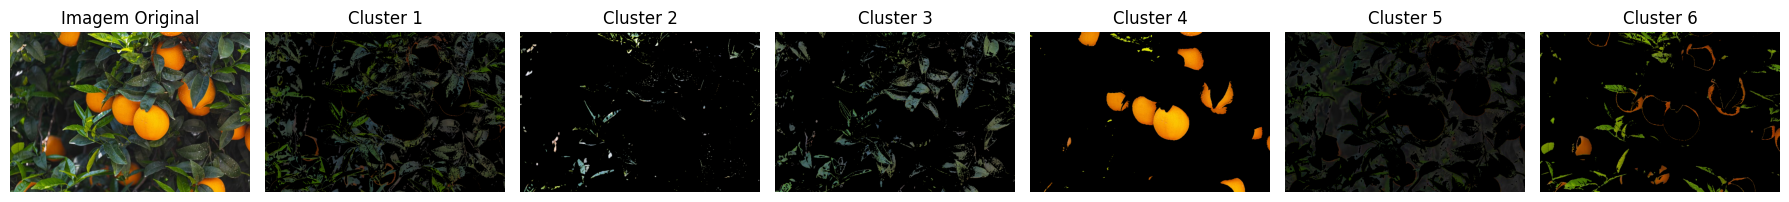

In [ ]:
# Importando as bibliotecas necessárias

# - numpy: para manipulação de arrays e operações matemáticas.
# - matplotlib.pyplot: para exibir as imagens.
# - sklearn.cluster.KMeans: o algoritmo de agrupamento (clustering) que vamos usar para segmentação.
# - requests, PIL e BytesIO: para carregar a imagem da internet e convertê-la para um formato compatível.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import requests
from PIL import Image
from io import BytesIO

# URL da imagem que queremos segmentar. Vamos usar uma imagem da internet
# e carregá-la diretamente no Colab.
url='https://img.freepik.com/free-photo/top-view-one-tennis-ball_23-2148796915.jpg?t=st=1731622061~exp=1731625661~hmac=9ef108375384e24b2bee653b72477a60b743c6e2c26e3b371d972bb9d8ad25f0&w=740'

url2 = 'https://img.freepik.com/premium-photo/closeup-beautiful-orange-tree-with-orange-large-round-oranges-surrounded-by-many-bright-green-leaves_116124-4580.jpg?w=740'

try:
    # Baixando e carregando a imagem com requests e PIL
    # Usamos requests para fazer uma requisição HTTP e obter o conteúdo da imagem.
    # PIL é usado para abrir a imagem diretamente da memória (BytesIO) e convertê-la para um array numpy.
    response = requests.get(url2)
    response.raise_for_status()  # Verifica se a requisição foi bem-sucedida

    # Abrindo a imagem com PIL e convertendo para um array numpy
    # Transformamos a imagem em um array numpy para manipulá-la com outras bibliotecas.
    image = Image.open(BytesIO(response.content))
    image = np.array(image)

    # Verificando as dimensões da imagem (h, w, c)
    h, w, c = image.shape  # Guardamos as dimensões da imagem para reformatá-la depois (altura, largura e canais).


    # Remodelando a imagem para ser uma lista de pixels
    # Neste passo, "achatamos" a imagem, convertendo-a de um array 3D (altura, largura, canais) para um array 2D
    # com o número de pixels como linhas e 3 colunas (para R, G, B). Isso é necessário porque o K-means trabalha
    # com uma lista de amostras (neste caso, os pixels), e cada amostra deve ser um vetor de características.

    # SUPONDO QUE A IMAGEM TENHA 100X100 PIXELS = 10000 PIXELS
    # ARRAY ORIGINAL (100,100,3)
    # NOVO ARRAY (10000,3)

    image_reshaped = image.reshape((-1, 3))  # Aqui estamos pegando os valores RGB de cada pixel

    # Aplicando K-means com 2 clusters
    # O K-means irá agrupar os pixels com base nos valores RGB. Estamos usando 2 clusters para separar o objeto e o fundo.

    num_clusters = 6

    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(image_reshaped)  # Ajustamos o modelo K-means com os dados dos pixels
    # Labels indicam a qual cluster cada pixel pertence
    labels = kmeans.labels_.reshape(h, w)  # Redimensionamos `labels` para as dimensões originais da imagem



    # Gerar as máscaras para cada cluster
    masks = []
    for i in range(num_clusters):
        mask = labels == i
        masks.append(mask)



    # Visualizando os resultados
    fig, ax = plt.subplots(1, num_clusters+1, figsize=(18, 6))

    # Imagem original
    ax[0].imshow(image)
    ax[0].set_title('Imagem Original')
    ax[0].axis('off')

    # Exibir as máscaras de cada cluster
    for i, mask in enumerate(masks):
        segmented_image = image * mask[..., np.newaxis]
        ax[i+1].imshow(segmented_image)
        ax[i+1].set_title(f'Cluster {i+1}')
        ax[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Tratamento de exceções para erros de conexão e ao abrir a imagem
except requests.exceptions.RequestException as e:
    print("Erro ao baixar a imagem:", e)
except Image.UnidentifiedImageError:
    print("Erro: o conteúdo baixado não é uma imagem válida.")
